In [7]:
# import libraries
import cv2
import tifffile
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import os
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Ellipse
from scipy.spatial.transform import Rotation as R
import matplotlib.colors as mcolors

In [8]:
# --setup--
velocity_data_path = r"..\For_batch_processing\full_track"
velocity_data_Caulobacter = os.path.join(velocity_data_path, 'velocity_Caulobacter_pair71.csv')
velocity_data_PAO1 = os.path.join(velocity_data_path, 'velocity_PAO1.csv')
velocity_data_E_coli = os.path.join(velocity_data_path, 'velocity_E_coli.csv')

velocity_data_Caulobacter = pd.read_csv(velocity_data_Caulobacter)
velocity_data_PAO1 = pd.read_csv(velocity_data_PAO1)
velocity_data_E_coli = pd.read_csv(velocity_data_E_coli)
# output directory
output_dir = r'..\For_batch_processing\extracted_info'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)


In [9]:
# center and normalize tracks

# --- 1. Caulobacter crescentus ---
R_trap_caulo = 8.0 / 2
df_caulo = velocity_data_Caulobacter.copy()
df_caulo = df_caulo[(df_caulo['frame'] >= 0) & (df_caulo['frame'] <= 201)].copy()

df_caulo['z'] += 0  # z_shift
df_caulo['capsule_radius'] = R_trap_caulo
df_caulo['r'] = np.sqrt(df_caulo['x']**2 + df_caulo['y']**2 + df_caulo['z']**2)
df_caulo['dist_from_wall'] = R_trap_caulo - df_caulo['r']
df_caulo['v_radial'] = np.gradient(df_caulo['r'])
velocity_data_show_Caulobacter = df_caulo

# --- 2. Pseudomonas aeruginosa (PAO1) ---
R_trap_pao1 = 8.1 / 2
df_pao1 = velocity_data_PAO1.copy()
# df_pao1 = df_pao1[(df_pao1['frame'] >= 0) & (df_pao1['frame'] <= 115)].copy()
df_pao1 = df_pao1[(df_pao1['frame'] >= 0) & (df_pao1['frame'] <= 201)].copy()

df_pao1['z'] += 1  # z_shift
df_pao1['capsule_radius'] = R_trap_pao1
df_pao1['r'] = np.sqrt(df_pao1['x']**2 + df_pao1['y']**2 + df_pao1['z']**2)
df_pao1['dist_from_wall'] = R_trap_pao1 - df_pao1['r']
df_pao1['v_radial'] = np.gradient(df_pao1['r'])
velocity_data_show_PAO1 = df_pao1

# --- 3. Escherichia coli ---
R_trap_ecoli = 8.8 / 2
df_ecoli = velocity_data_E_coli.copy()
# df_ecoli = df_ecoli[(df_ecoli['frame'] >= 0) & (df_ecoli['frame'] <= 201)].copy()
df_ecoli = df_ecoli[(df_ecoli['frame'] >= 0) & (df_ecoli['frame'] <= 201)].copy()

df_ecoli['z'] += -1  # z_shift
df_ecoli['capsule_radius'] = R_trap_ecoli
df_ecoli['r'] = np.sqrt(df_ecoli['x']**2 + df_ecoli['y']**2 + df_ecoli['z']**2)
df_ecoli['dist_from_wall'] = R_trap_ecoli - df_ecoli['r']
df_ecoli['v_radial'] = np.gradient(df_ecoli['r'])
velocity_data_show_E_coli = df_ecoli

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine data and fix the index issue
df_caulo['species'] = 'C. crescentus'
df_pao1['species'] = 'P. aeruginosa'
df_ecoli['species'] = 'E. coli'

# Reset index here to avoid the ValueError
df_all = pd.concat([df_caulo, df_pao1, df_ecoli]).reset_index(drop=True)

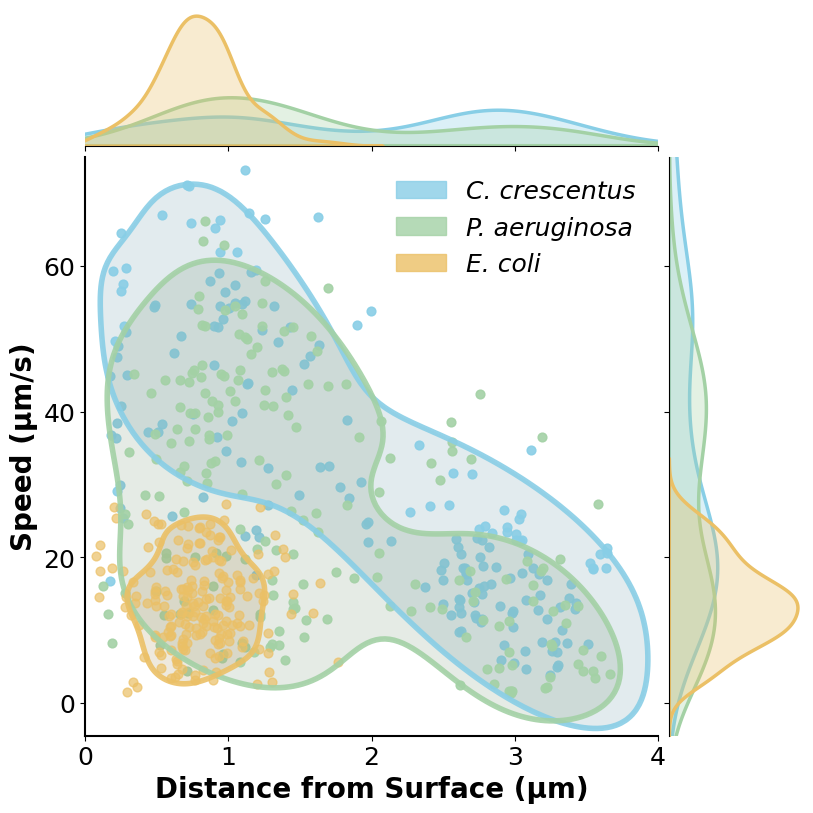

In [11]:
# final joint
# ==========================================
# UPDATED JOINT PLOT WITH NEW PALETTE
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# 1. NEW COHESIVE PALETTE (Matches Fig 1-3 & Density Plots)

palette = {
    'C. crescentus': '#88CEE6', # Original Pastel Blue
    'P. aeruginosa': '#A3D1A5', # Original Sage Green
    'E. coli':       '#EBC066'  # Muted Gold (Fainter than Ochre, but high contrast)
}

# ==========================================
# FONT SIZE KNOBS
# ==========================================
FS_LABEL  = 20    # Axis titles
FS_TICKS  = 18    # Numbers on the axes
FS_LEGEND = 18    # Species names
# ==========================================

# 2. Setup Plot & Order
species_order = ['C. crescentus', 'P. aeruginosa', 'E. coli']
g = sns.JointGrid(data=df_all, x='dist_from_wall', y='velocity', 
                  height=8, ratio=4, space=0.08)
g.fig.set_figheight(8)  # Change height independently

g.fig.set_figwidth(8)  # Change width independently

# 3. Main Plot Logic (Flat Fill + Sharp Outline)
for spec in species_order:
    df_spec = df_all[df_all['species'] == spec]
    color = palette[spec]
    
    # Layer 1: Flat Fill (Slightly higher alpha for visibility of pastel)
    sns.kdeplot(data=df_spec, x='dist_from_wall', y='velocity', ax=g.ax_joint, 
                color=color, fill=True, alpha=0.18, levels=2, thresh=0.3, bw_adjust=1.1)
    
    # Layer 2: Bold Outline (Sharp definition)
    sns.kdeplot(data=df_spec, x='dist_from_wall', y='velocity', ax=g.ax_joint, 
                color=color, fill=False, alpha=0.9, levels=1, thresh=0.3, 
                bw_adjust=1.1, linewidths=4)
    
    # Layer 3: High-Visibility Hollow Points (Sampling 100 points)
    # sns.scatterplot(data=df_spec, 
    #                 x='dist_from_wall', y='velocity', ax=g.ax_joint,
    #                 color=color, s=45, alpha=0.9, marker='o', 
    #                 facecolors='none', edgecolors=color, linewidths=2.0)
    if spec == 'E. coli':
        sns.scatterplot(data=df_spec, 
                x='dist_from_wall', y='velocity', ax=g.ax_joint,
                color=color, s=40, alpha=0.7, marker='o', 
                facecolors=color, edgecolors=color, linewidths=1.0)
    else:
        sns.scatterplot(data=df_spec, 
                x='dist_from_wall', y='velocity', ax=g.ax_joint,
                color=color, s=40, alpha=0.9, marker='o', 
                facecolors=color, edgecolors=color, linewidths=1.0)
# 4. Marginals Logic (Clean Silhouettes)
for spec in species_order:
    color = palette[spec]
    # Marginal X
    sns.kdeplot(data=df_all[df_all['species'] == spec], x='dist_from_wall', 
                ax=g.ax_marg_x, color=color, fill=True, alpha=0.3, 
                linewidth=2.5, common_norm=False)
    # Marginal Y
    sns.kdeplot(data=df_all[df_all['species'] == spec], y='velocity', 
                ax=g.ax_marg_y, color=color, fill=True, alpha=0.3, 
                linewidth=2.5, common_norm=False)

# 5. Final Formatting
g.ax_joint.set_xlabel("Distance from Surface (µm)", fontweight='bold', fontsize=FS_LABEL)
g.ax_joint.set_ylabel("Speed (µm/s)", fontweight='bold', fontsize=FS_LABEL)

g.ax_joint.tick_params(axis='both', which='major', labelsize=FS_TICKS)

# Axis Limits & reference line
g.ax_joint.set_xlim(0, 4)
g.ax_joint.set_ylim(-4.5, 75)

# Legend (Using Patches for clean squares)
legend_handles = [mpatches.Patch(color=palette[spec], label=spec, alpha=0.8) for spec in species_order]
g.ax_joint.legend(
    handles=legend_handles, 
    frameon=False, 
    loc='upper right', 
    fontsize=FS_LEGEND,
    prop={'size': FS_LEGEND, 'style': 'italic'} # This handles the italics
)
# Ticks
g.ax_joint.set_xticks([0, 1, 2, 3,4])
g.ax_joint.set_yticks([0, 20, 40, 60])

# axis thickness
g.ax_joint.spines['bottom'].set_linewidth(1.5)
g.ax_joint.spines['left'].set_linewidth(1.5)

# name = 'speed_vs_distance_jointplot_v3.png'
# plt.savefig(name, format='png', dpi=900, transparent=False, bbox_inches='tight')

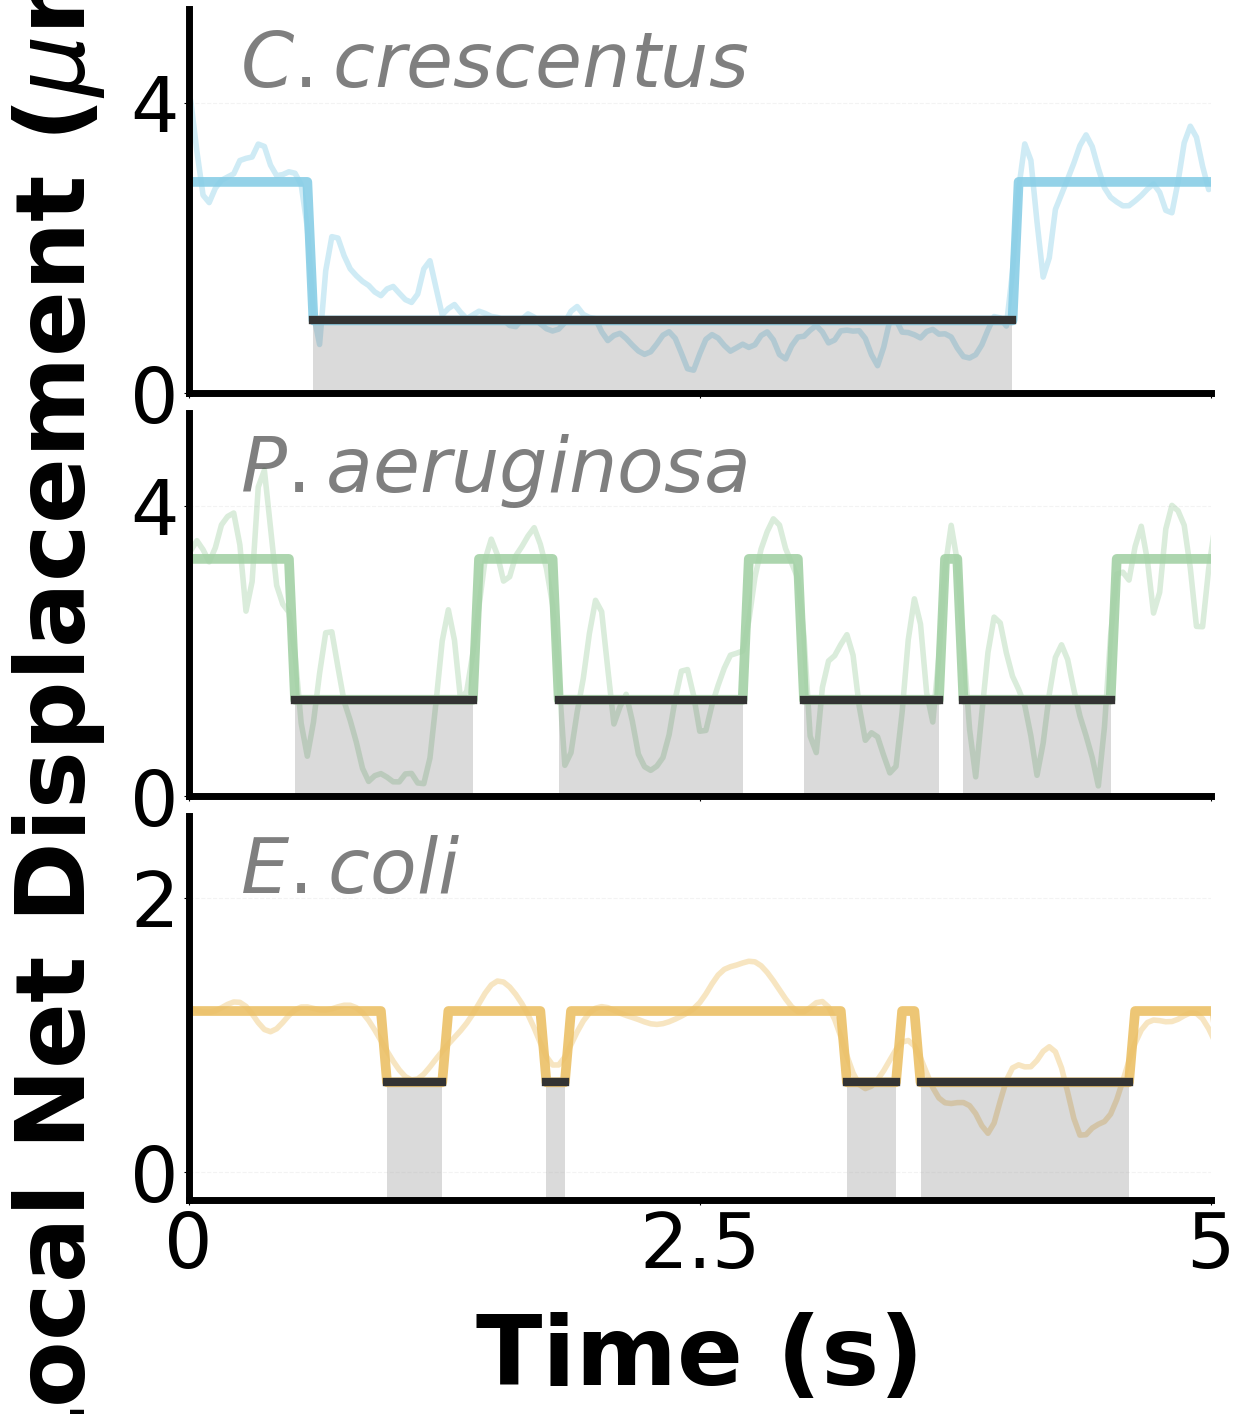

In [12]:
# ==========================================
# FINAL LND VS T: CENTERED STRAIN WATERMARKS
# ==========================================
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FixedLocator
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from scipy.ndimage import median_filter, gaussian_filter1d

species_stack = ['C. crescentus', 'P. aeruginosa', 'E. coli']
dfs_stack = [df_caulo, df_pao1, df_ecoli]
palette = {'C. crescentus': '#4c72b0', 'P. aeruginosa': '#55a868', 'E. coli': '#81d4fa'}
low_state_stats = {} 

# --- KNOB 1: STYLE ---
# FS_LABEL = 60 
FS_LABEL = 70
# FS_TICKS = 50
FS_TICKS = 55
DT = 0.030 
# Time-shifting logic for x-axis
RELATIVE_TICKS_TO_SHOW = [0, 2.5, 5] 
PHYSICAL_TICK_POSITIONS = [x + 0.5 for x in RELATIVE_TICKS_TO_SHOW]

# palette = {
#     'C. crescentus': '#88CEE6', # Pastel Blue
#     'P. aeruginosa': '#A3D1A5', # Sage Green
#     'E. coli':       '#C2AFD7'  # Dusty Purple
# }
# COLOR_LOW_STATE = '#E89DA0' # Pastel Red matches Density Map

palette = {
    'C. crescentus': '#88CEE6', 
    'P. aeruginosa': '#A3D1A5', 
    'E. coli':       '#EBC066'  
}
# Change this to a dark neutral so it pops against ORANGE, GREEN, and BLUE
COLOR_LOW_STATE = '#333333'  # Dark Charcoal
COLOR_FLOOR = '#F5F5F5'

# --- KNOB 2: Y-AXIS TICKS ---
Y_TICKS_CONFIG = {
    'C. crescentus': [0, 4],
    'P. aeruginosa': [0, 4],
    'E. coli':       [0, 2]
}

# --- KNOB 3: SIGNAL PROCESSING ---
CONF_WINDOW_SEC = 0.1
C_WIN = int(CONF_WINDOW_SEC / DT)
filter_tuning = {
    'C. crescentus': {'backbone_sigma': 1, 'step_filter': 5},
    'P. aeruginosa': {'backbone_sigma': 1, 'step_filter': 5},
    'E. coli':       {'backbone_sigma': 3, 'step_filter': 5} 
}

# NEW: Container to store ranges for Density Map synchronization
detected_low_state_ranges = {}

def shift_label(x, pos):
    return f'{x - 0.5:g}'

# ==========================================
# EXECUTION: TOP-CENTER BLACK TITLES
# ==========================================
# fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
# fig, axes = plt.subplots(3, 1, figsize=(13, 14), sharex=True)
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

for i, (spec, df) in enumerate(zip(species_stack, dfs_stack)):
    ax = axes[i]
    color = palette[spec]
    
    # --- Part A & B: Calculations ---
    sig = filter_tuning[spec]['backbone_sigma']
    xs = gaussian_filter1d(df['x'].values, sigma=sig)
    ys = gaussian_filter1d(df['y'].values, sigma=sig)
    zs = gaussian_filter1d(df['z'].values, sigma=sig)
    pos = np.stack([xs, ys, zs], axis=1)
    
    lnd = np.zeros(len(pos))
    for j in range(C_WIN, len(pos)):
        lnd[j] = np.linalg.norm(pos[j] - pos[j-C_WIN])
    lnd[:C_WIN] = lnd[C_WIN] 
    
    f_size = filter_tuning[spec]['step_filter']
    smooth_lnd = median_filter(lnd, size=f_size)
    km = KMeans(n_clusters=2, n_init=10, random_state=42).fit(smooth_lnd.reshape(-1, 1))
    centers = km.cluster_centers_.flatten()
    low_cluster_idx = np.argmin(centers)
    lnd_step = np.array([centers[label] for label in km.labels_])
    is_low = (km.labels_ == low_cluster_idx)
    time = df['frame'].values * DT

    # --- NEW: EXTRACT DETECTED RANGES ---
    ranges = []
    if np.any(is_low):
        # Identify blocks of "True" in the is_low mask
        diff = np.diff(is_low.astype(int))
        starts = np.where(diff == 1)[0] + 1
        ends = np.where(diff == -1)[0] + 1
        
        # Handle cases where state starts or ends at the array boundaries
        if is_low[0]: starts = np.r_[0, starts]
        if is_low[-1]: ends = np.r_[ends, len(is_low)]
        
        for s, e in zip(starts, ends):
            ranges.append((time[s], time[e-1]))
    
    detected_low_state_ranges[spec] = ranges

    # --- Part C: Plotting ---
    ax.plot(time, lnd, color=color, alpha=0.4, lw=4, zorder=1)
    ax.plot(time, lnd_step, color=color, alpha=0.9, lw=7.0, zorder=2)
    lnd_low_only = np.where(is_low, lnd_step, np.nan)
    ax.plot(time, lnd_low_only, color=COLOR_LOW_STATE, alpha=1.0, lw=6.0, zorder=3)
    ax.fill_between(time, -0.2, lnd_low_only, color=COLOR_LOW_STATE, alpha=0.18, linewidth=0, zorder=1)

    # --- Part D: Polish & Top-Center Strain Label ---
    ax.text(0.05, 0.95, f"$\mathit{{{spec}}}$", 
            transform=ax.transAxes, 
            fontsize=FS_TICKS,
            color='black', 
            # alpha=0.7, 
            alpha = 0.5,
            ha='left', va='top', 
            fontweight='bold')

    # Y-Axis Logic
    ticks = Y_TICKS_CONFIG[spec]
    ax.yaxis.set_major_locator(FixedLocator(ticks))
    if i == 0 or i == 1:
        ax.set_ylim(0.0, max(ticks) * 1.32) 
    else:
        ax.set_ylim(-0.2, max(ticks) * 1.3) 
    
    if i == 1:
        ax.set_ylabel(r"Local Net Displacement ($\mu$m)", fontsize=FS_LABEL, fontweight='bold', labelpad=20)
        # shift lower
        ax.yaxis.set_label_coords(-0.08, 0.3)
    else:
        ax.set_ylabel("") 

    # X-Axis Logic
    ax.set_xlim(0.5, 5.5)
    ax.xaxis.set_major_locator(FixedLocator(PHYSICAL_TICK_POSITIONS))
    ax.xaxis.set_major_formatter(FuncFormatter(shift_label))
    
    ax.tick_params(axis='both', which='major', labelsize=FS_TICKS)
    ax.grid(axis='y', linestyle='--', alpha=0.15)
    sns.despine(ax=ax)

axes[2].set_xlabel("Time (s)", fontsize=FS_LABEL, fontweight='bold', labelpad=20)
plt.subplots_adjust(left=0.22, right=0.95, top=0.95, bottom=0.1, hspace=0.05)

# Axis thickness
for ax in axes:
    # ax.spines['bottom'].set_linewidth(4)
    # ax.spines['left'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(5)
    ax.spines['left'].set_linewidth(5)

# name = 'LND_vs_time_v3.png'
# plt.savefig(name, format='png', dpi=900, transparent=False, bbox_inches='tight')

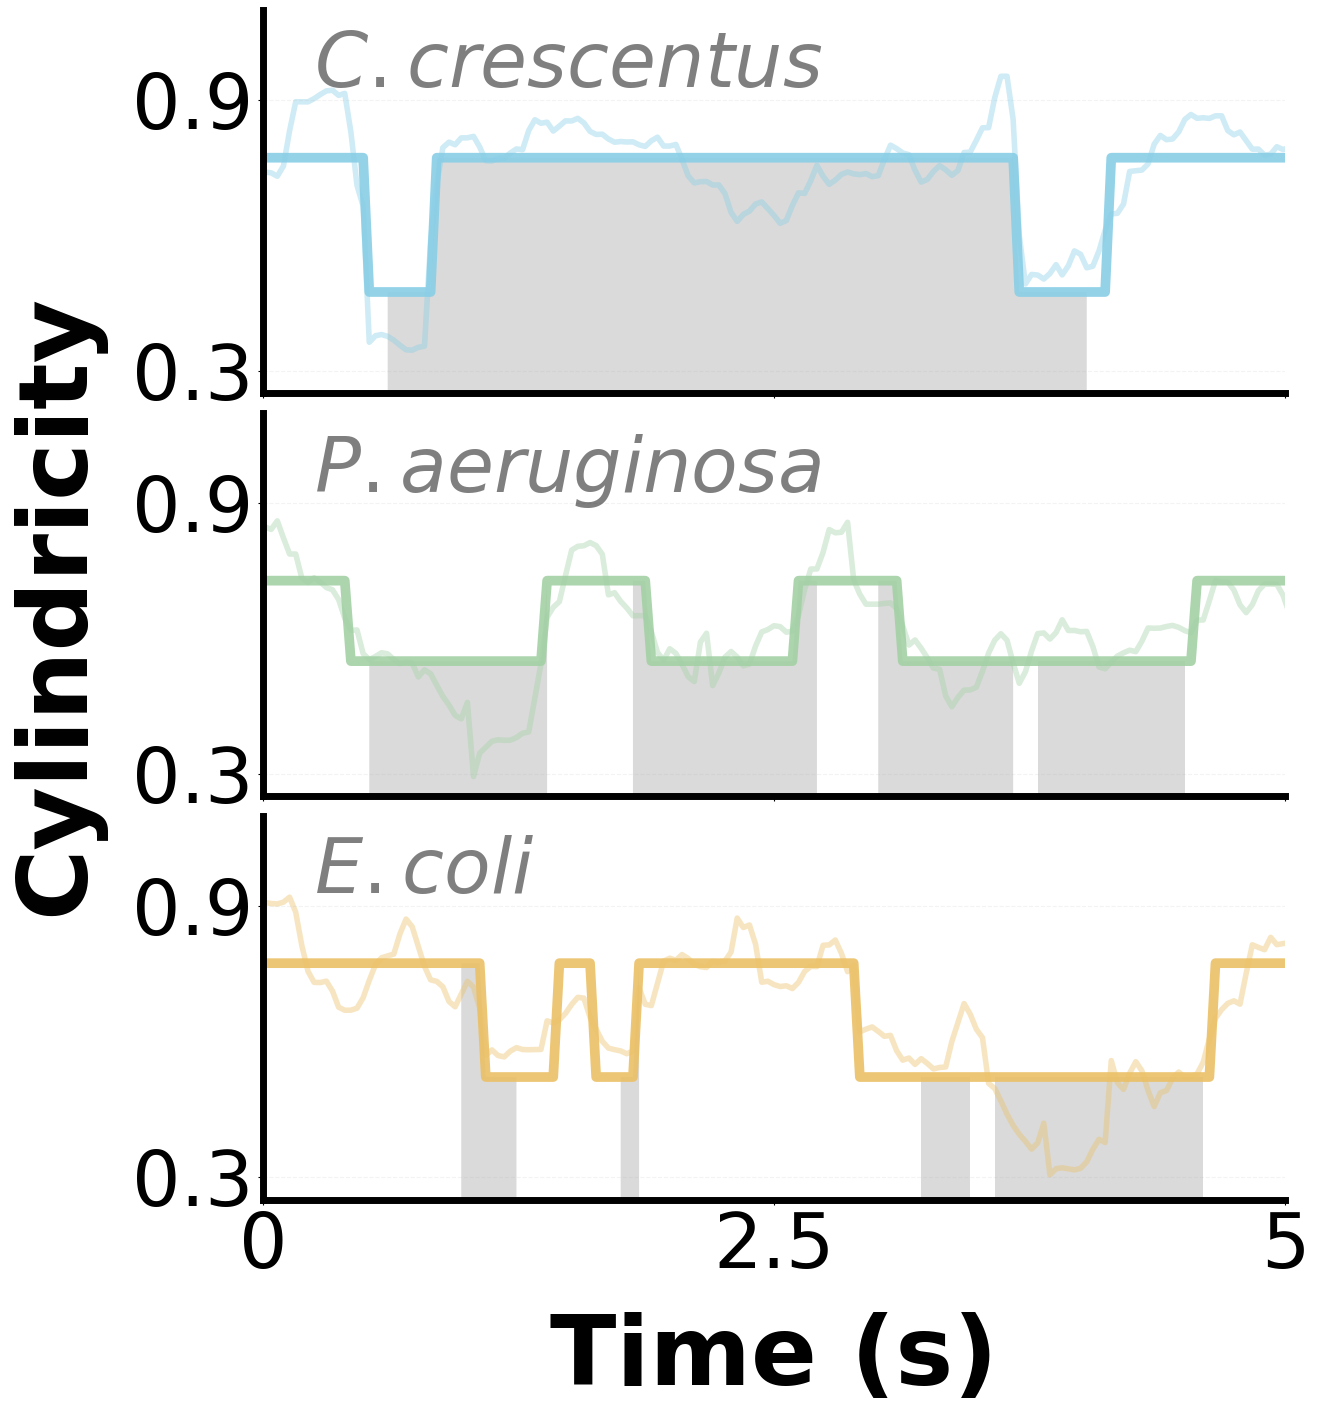

In [13]:
# ==========================================
# FINAL CYL VS T: SYNCED TO LND STYLE
# ==========================================
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FixedLocator, MaxNLocator
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from scipy.ndimage import median_filter, gaussian_filter1d

# --- KNOB 1: STYLE (Synced with LND) ---
# FS_LABEL = 40 
# FS_TICKS = 32
# FS_LABEL = 60 
FS_LABEL = 70 
# FS_TICKS = 50
FS_TICKS = 55
DT = 0.030 
RELATIVE_TICKS_TO_SHOW = [0, 2.5, 5] 
PHYSICAL_TICK_POSITIONS = [x + 0.5 for x in RELATIVE_TICKS_TO_SHOW]

# palette = {
#     'C. crescentus': '#88CEE6', # Pastel Blue
#     'P. aeruginosa': '#A3D1A5', # Sage Green
#     'E. coli':       '#C2AFD7'  # Dusty Purple
# }
# COLOR_LOW_STATE = '#E89DA0' # Pastel Red (Matches LND segments)

palette = {
    'C. crescentus': '#88CEE6', 
    'P. aeruginosa': '#A3D1A5', 
    'E. coli':       '#EBC066'  
}
# Change this to a dark neutral so it pops against ORANGE, GREEN, and BLUE
COLOR_LOW_STATE = '#333333'  # Dark Charcoal
COLOR_FLOOR = '#F5F5F5'

# --- KNOB 2: PARAMETERS ---
filter_tuning = {
    'C. crescentus': {'backbone_sigma': 2.0, 'step_filter': 5},
    'P. aeruginosa': {'backbone_sigma': 2.0, 'step_filter': 5},
    'E. coli':       {'backbone_sigma': 2.0, 'step_filter': 5}
}
CYL_WINDOW_SEC = 0.1 * np.pi
WIN_CYL = int(CYL_WINDOW_SEC / DT)

def shift_label(x, pos):
    return f'{x - 0.5:g}'

# ==========================================
# EXECUTION
# ==========================================
# fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
# fig, axes = plt.subplots(3, 1, figsize=(13, 14), sharex=True)
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

for i, (spec, df) in enumerate(zip(species_stack, dfs_stack)):
    ax = axes[i]
    color = palette[spec]
    time = df['frame'].values * DT
    
    # --- Part A: Cylindricity Calculation ---
    sig = filter_tuning[spec]['backbone_sigma']
    xs = gaussian_filter1d(df['x'], sigma=sig)
    ys = gaussian_filter1d(df['y'], sigma=sig)
    zs = gaussian_filter1d(df['z'], sigma=sig)
    
    v_vec = np.stack([np.gradient(xs), np.gradient(ys), np.gradient(zs)], axis=1)
    a_vec = np.stack([np.gradient(v_vec[:,0]), np.gradient(v_vec[:,1]), np.gradient(v_vec[:,2])], axis=1)
    v_mag = np.linalg.norm(v_vec, axis=1)
    v_cross_a_mag = np.linalg.norm(np.cross(v_vec, a_vec), axis=1)
    
    radius = (v_mag**3) / (v_cross_a_mag + 1e-6)
    r_series = pd.Series(radius)
    r_cv = r_series.rolling(window=WIN_CYL, center=True).std() / (r_series.rolling(window=WIN_CYL, center=True).mean() + 1e-6)
    cyl_raw = (1 / (1 + r_cv)).ffill().bfill().values
    
    f_size = filter_tuning[spec]['step_filter']
    smooth_cyl = median_filter(cyl_raw, size=f_size)
    km_cyl = KMeans(n_clusters=2, n_init=10, random_state=42).fit(smooth_cyl.reshape(-1, 1))
    # Ensure indices match the sorted centers to keep "Stability" consistent
    centers = km_cyl.cluster_centers_.flatten()
    cyl_step = np.array([centers[label] for label in km_cyl.labels_])

    # --- Part B: Plotting ---
    # 1. Red Sync-Shade (Using detected_low_state_ranges from LND code)
    if spec in detected_low_state_ranges:
        is_low = np.zeros_like(time, dtype=bool)
        for start_t, end_t in detected_low_state_ranges[spec]:
            is_low |= (time >= start_t) & (time <= end_t)
        
        # Fill from 0 up to the step curve where LND was low
        ax.fill_between(time, 0, cyl_step, where=is_low, 
                        color=COLOR_LOW_STATE, alpha=0.18, linewidth=0, zorder=0)

    # 2. Cylindricity Lines (Synced weights/alphas)
    ax.plot(time, cyl_raw, color=color, alpha=0.4, lw=4, zorder=1)
    ax.plot(time, cyl_step, color=color, alpha=0.9, lw=7.0, zorder=2)
    
    # --- Part C: Polish & Titles ---
    # Top-Center Black Title (Italicized)
    ax.text(0.05, 0.95, f"$\mathit{{{spec}}}$", 
            transform=ax.transAxes, 
            fontsize=FS_TICKS,
            color='black', 
            # alpha=0.7, 
            alpha = 0.5,
            ha='left', va='top', fontweight='bold')

    # Y-Axis Logic
    ax.set_ylim(0.25, 1.1) # Standardized for Cylindricity (0 to 1 scale)
    ax.set_yticks([0.3, 0.9])
    
    if i == 1:
        ax.set_ylabel("Cylindricity", fontsize=FS_LABEL, fontweight='bold', labelpad=20)
    else:
        ax.set_ylabel("")

    # X-Axis Logic
    ax.set_xlim(0.5, 5.5)
    ax.xaxis.set_major_locator(FixedLocator(PHYSICAL_TICK_POSITIONS))
    ax.xaxis.set_major_formatter(FuncFormatter(shift_label))
    
    # Grid and Tick polish
    ax.tick_params(axis='both', which='major', labelsize=FS_TICKS)
    ax.grid(axis='y', linestyle='--', alpha=0.15)
    sns.despine(ax=ax)

# Final Layout Touches
axes[2].set_xlabel("Time (s)", fontsize=FS_LABEL, fontweight='bold', labelpad=20)
plt.subplots_adjust(left=0.22, right=0.95, top=0.95, bottom=0.1, hspace=0.05) # Narrow hspace for column feel

# axis thickness
for ax in axes:
    # ax.spines['bottom'].set_linewidth(4)
    # ax.spines['left'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(5)
    ax.spines['left'].set_linewidth(5)

# name = 'cylindricity_vs_time_v3.png'
# plt.savefig(name, format='png', dpi=900, transparent=False, bbox_inches='tight')

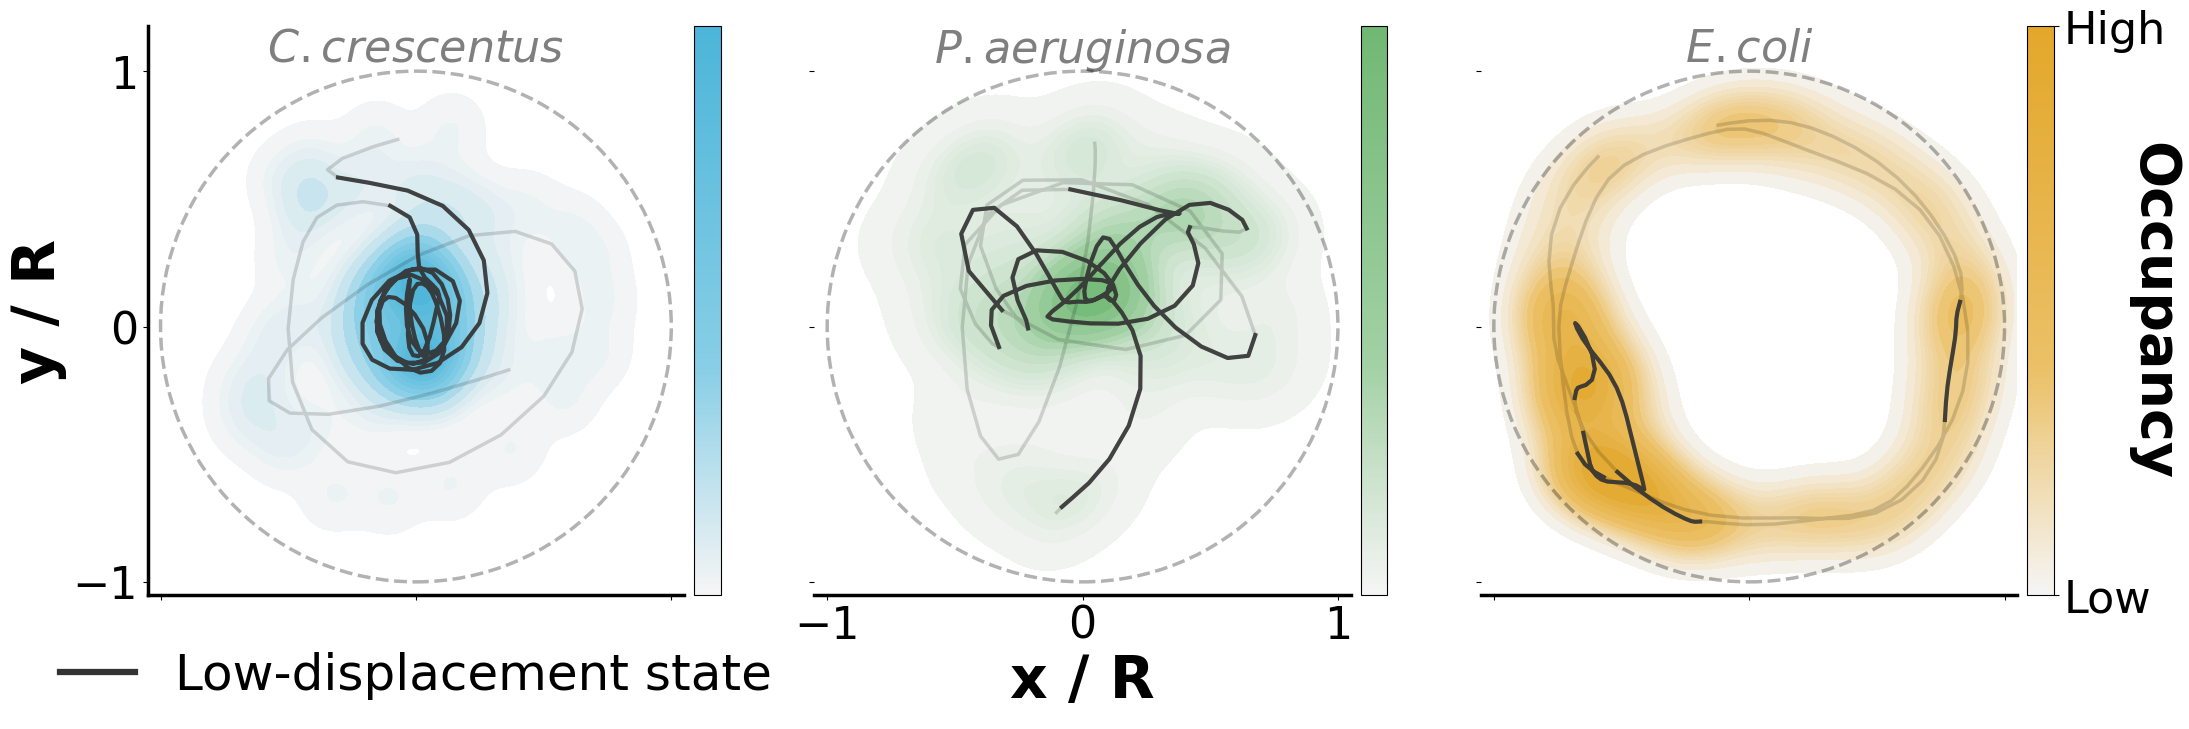

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.colors as mc
import colorsys

# ==========================================
# KNOBS: VISIBILITY & COLORS
# ==========================================
# Controls how quickly the color appears (0.5 is a balanced glow)
LOW_DENSITY_GLOW = 0.6

# palette = {
#     'C. crescentus': '#88CEE6', 
#     'P. aeruginosa': '#A3D1A5', 
#     'E. coli':       '#C2AFD7'  
# }

# palette = {
#     'C. crescentus': '#88CEE6', # Keep your Pastel Blue
#     'P. aeruginosa': '#A3D1A5', # Keep your Sage Green
#     'E. coli':       '#E69F00'  # Ochre/Orange (Massive contrast to Blue)
# }
# COLOR_LOW_STATE = '#E89DA0' 
# COLOR_FLOOR = '#F5F5F5' 


# palette = {
#     'C. crescentus': '#88CEE6', 
#     'P. aeruginosa': '#A3D1A5', 
#     'E. coli':       '#E69F00'  
# }
palette = {
    'C. crescentus': '#88CEE6', 
    'P. aeruginosa': '#A3D1A5', 
    'E. coli':       '#EBC066'  
}
# Change this to a dark neutral so it pops against ORANGE, GREEN, and BLUE
COLOR_LOW_STATE = '#333333'  # Dark Charcoal
COLOR_FLOOR = '#F5F5F5'

# Aesthetics (Matches your preferred large-scale version)
# FS_TITLE, FS_LABEL, FS_TICKS = 22, 40, 32
# FS_TITLE, FS_LABEL, FS_TICKS = 22, 50, 40
FS_TITLE, FS_LABEL, FS_TICKS = 22, 42, 32
LW_GHOST, ALPHA_GHOST = 2.5, 0.15
LW_STATE, ALPHA_STATE = 3, 0.9

# Time Filter
DT = 0.030  
T_START, T_END = 1, 5.5
FRAME_START, FRAME_END = int(T_START / DT), int(T_END / DT)

spec_tuning = {
    'C. crescentus': {'thresh': 0.01, 'bw': 0.8, 'levels': 15},
    'P. aeruginosa': {'thresh': 0.01, 'bw': 0.8, 'levels': 15},
    'E. coli':       {'thresh': 0.05, 'bw': 0.5, 'levels': 15} 
}

state_labels = {
    'C. crescentus': 'Low-displacement states',
    'P. aeruginosa': 'Detected Impeded',
    'E. coli':       'Detected Tumble'
}

# ==========================================
# PLOTTING
# ==========================================
# fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharey=True)
fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharey=True)
# plt.subplots_adjust(wspace=0.45) 
plt.subplots_adjust(wspace=0) 

for i, (spec, df_full) in enumerate(zip(species_stack, dfs_stack)):
    ax = axes[i]
    color = palette[spec]
    
    df = df_full[(df_full['frame'] >= FRAME_START) & (df_full['frame'] <= FRAME_END)].copy()
    R_cap = df['capsule_radius'].iloc[0]
    
    x_smooth = gaussian_filter1d(df['x'], sigma=1.5)
    y_smooth = gaussian_filter1d(df['y'], sigma=1.5)
    
    xn, yn = df['x']/R_cap, df['y']/R_cap
    xsn, ysn = x_smooth/R_cap, y_smooth/R_cap 
    
    # --- NON-LINEAR GLOW COLORMAP LOGIC ---
    def adjust_lightness(c_hex, amount=0.7):
        c = mc.to_rgb(c_hex)
        c = colorsys.rgb_to_hls(*c)
        return mc.to_hex(colorsys.hls_to_rgb(c[0], max(0, min(1, c[1] * amount)), c[2]))

    darker_color = adjust_lightness(color, 0.8)
    pos = max(0.01, 1.0 - LOW_DENSITY_GLOW) # Where species color begins
    
    cdict = {
        'red':   [(0.0, mc.to_rgb(COLOR_FLOOR)[0], mc.to_rgb(COLOR_FLOOR)[0]),
                  (pos, mc.to_rgb(color)[0], mc.to_rgb(color)[0]),
                  (1.0, mc.to_rgb(darker_color)[0], mc.to_rgb(darker_color)[0])],
        'green': [(0.0, mc.to_rgb(COLOR_FLOOR)[1], mc.to_rgb(COLOR_FLOOR)[1]),
                  (pos, mc.to_rgb(color)[1], mc.to_rgb(color)[1]),
                  (1.0, mc.to_rgb(darker_color)[1], mc.to_rgb(darker_color)[1])],
        'blue':  [(0.0, mc.to_rgb(COLOR_FLOOR)[2], mc.to_rgb(COLOR_FLOOR)[2]),
                  (pos, mc.to_rgb(color)[2], mc.to_rgb(color)[2]),
                  (1.0, mc.to_rgb(darker_color)[2], mc.to_rgb(darker_color)[2])]
    }
    custom_cmap = LinearSegmentedColormap(f"{spec}_glow", cdict)
    
    # 2. Density Map
    sns.kdeplot(x=xn, y=yn, ax=ax, fill=True, cmap=custom_cmap, 
                alpha=1.0, 
                thresh=spec_tuning[spec]['thresh'], 
                levels=spec_tuning[spec]['levels'], 
                bw_adjust=spec_tuning[spec]['bw'], 
                zorder=1)
    
    # 3. Ghosted Track
    ax.plot(xsn, ysn, color='black', lw=LW_GHOST, alpha=ALPHA_GHOST, zorder=2)
    
    # 4. UNIVERSAL RED OVERLAY
    low_state_mask = np.zeros(len(df), dtype=bool)
    current_times = df['frame'].values * DT
    for t_start, t_end in detected_low_state_ranges[spec]:
        low_state_mask |= (current_times >= t_start) & (current_times <= t_end)
    
    x_low, y_low = xsn.copy(), ysn.copy()
    x_low[~low_state_mask], y_low[~low_state_mask] = np.nan, np.nan
    ax.plot(x_low, y_low, color=COLOR_LOW_STATE, lw=LW_STATE, alpha=ALPHA_STATE, 
            zorder=5, label=state_labels[spec])

    # 5. Boundary Reference
    circle = plt.Circle((0, 0), 1.0, color='black', fill=False, ls='--', lw=2.5, alpha=0.3, zorder=6)
    ax.add_patch(circle)

    # --- ADDED: TOP-CENTER STRAIN NAME ---
    ax.text(0.5, 1, f"$\mathit{{{spec}}}$", 
            transform=ax.transAxes, 
            fontsize=FS_TICKS, 
            color='black', 
            # alpha=1, 
            alpha = 0.5,
            ha='center', va='top', fontweight='bold', zorder=10)
    
    # 6. Colorbars
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    sm = ScalarMappable(cmap=custom_cmap, norm=Normalize(vmin=0, vmax=1))
    cbar = fig.colorbar(sm, cax=cax)
    
    if i == 2:
        cbar.set_ticks([0, 1])
        cbar.set_ticklabels(['Low', 'High'], fontsize=FS_TICKS)
        cax.set_ylabel('Occupancy', fontsize=FS_LABEL-2, fontweight='bold', rotation=-90, labelpad=10)
    else:
        cbar.set_ticks([])
    
    # Formatting
    ax.set_aspect('equal')
    ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.175)

    if i == 1:
        ax.set_xlabel("x / R", fontsize=FS_LABEL, fontweight='bold')
        ax.set_xticks([-1, 0, 1])
    else:
        ax.set_xlabel("")   
        ax.set_xticks([-1, 0, 1])
        # remove tick labels
        ax.set_xticklabels([])

    if i == 0: 
        ax.set_ylabel("y / R", fontsize=FS_LABEL, fontweight='bold')
        ax.set_yticks([-1, 0, 1])
    
    ax.tick_params(labelsize=FS_TICKS)
    sns.despine(ax=ax, left=(i != 0), bottom=False)
    # Place this after the loop
axes[0].legend(handles=[plt.Line2D([0], [0], color=COLOR_LOW_STATE, lw=LW_STATE*1.5)],
               labels=['Low-displacement state'],
               loc='upper center', 
            #    bbox_to_anchor=(0.5, -0.04), # Adjust this to put it under the x-axis
                bbox_to_anchor=(0.5, -0.02),
               frameon=False, 
            #    fontsize=FS_TICKS,
                fontsize=FS_TICKS+4,
               handlelength=1.5,
               ncol=1)

plt.tight_layout(w_pad=0)

# adjust axis thickness
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
# name = 'occupancy_heatmaps_v3.png'
# plt.savefig(name, format='png', dpi=900, transparent=False, bbox_inches='tight')